In [ ]:
import warnings; warnings.filterwarnings('ignore')
import pyodbc, numpy as np, pandas as pd
cnxn = pyodbc.connect('DSN=DSNContoso;DATABASE=Contoso V2 100K')
print('Connected: Contoso V2 100K')

Connected: Contoso V2 100K


New Notebook Created by Jupyter MCP Server

# Area 3 — Product & Category Analysis
**Contoso V2 100K | Jan–Apr 2024 vs Jan–Apr 2023**

This notebook answers 10 business questions about product category performance, brand profitability, and product-level risk across the Contoso portfolio.

---

---
### 3.L1.01 — Category and Brand Health

| Lens | Value |
|---|---|
| **Who** | P1 — CCO |
| **What** | Total Revenue (M01), Gross Margin % (M09) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By product category and brand |
| **Why** | Determine which product areas are growing the business and which are diluting profit |
| **How** | Revenue and margin % side by side by category, with YoY change |

**Full question:** Which product categories are growing revenue and maintaining or improving gross margin in Jan–Apr 2024 vs. Jan–Apr 2023, and which are declining in revenue or losing margin?

**Pyramid level:** L1 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** Category-level revenue and margin combined with YoY change gives the executive a single view to classify categories as grow/defend/rationalize.
**Grain:** One row per product category (8 categories) per year.

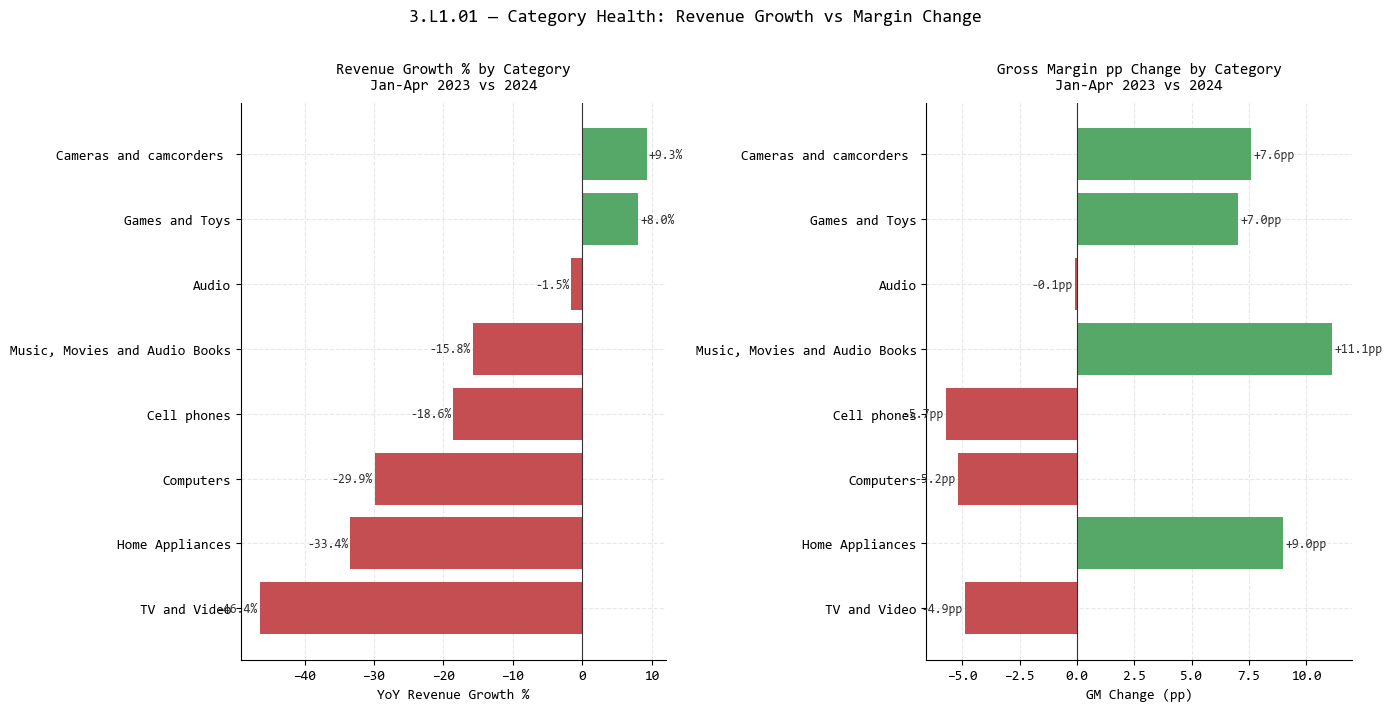

,CategoryName,Rev23,Rev24,RevGrowthPct,GM23,GM24,GMChange
0,TV and Video,"$506,975","$271,710",-46.4%,-37.4%,-42.2%,-4.9pp
1,Home Appliances,"$621,211","$413,694",-33.4%,-46.7%,-37.7%,+9.0pp
2,Computers,"$1,269,422","$889,823",-29.9%,-34.8%,-39.9%,-5.2pp
3,Cell phones,"$612,760","$498,998",-18.6%,-43.5%,-49.3%,-5.7pp
4,"Music, Movies and Audio Books","$222,385","$187,326",-15.8%,-36.4%,-25.3%,+11.1pp
5,Audio,"$64,204","$63,214",-1.5%,-42.5%,-42.5%,-0.1pp
6,Games and Toys,"$24,516","$26,488",+8.0%,-53.1%,-46.0%,+7.0pp
7,Cameras and camcorders,"$192,788","$210,742",+9.3%,-28.9%,-21.3%,+7.6pp


In [ ]:
# 3.L1.01 - Category health: revenue + margin YoY
df_cat_health_raw = pd.read_sql("""
    SELECT
        p.CategoryName,
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice)                                                       AS Revenue,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice),0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY p.CategoryName, YEAR(s.OrderDate)
""", cnxn)

df23 = df_cat_health_raw[df_cat_health_raw['Year']==2023][['CategoryName','Revenue','GrossMarginPct']].rename(columns={'Revenue':'Rev23','GrossMarginPct':'GM23'})
df24 = df_cat_health_raw[df_cat_health_raw['Year']==2024][['CategoryName','Revenue','GrossMarginPct']].rename(columns={'Revenue':'Rev24','GrossMarginPct':'GM24'})
df_cat_health = df23.merge(df24, on='CategoryName')
df_cat_health['RevGrowthPct'] = (df_cat_health['Rev24'] - df_cat_health['Rev23']) / df_cat_health['Rev23'] * 100
df_cat_health['GMChange'] = df_cat_health['GM24'] - df_cat_health['GM23']
df_cat_health = df_cat_health.sort_values('RevGrowthPct', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

ax = axes[0]
colors = ['#C44E52' if v < 0 else '#55A868' for v in df_cat_health['RevGrowthPct']]
bars = ax.barh(df_cat_health['CategoryName'], df_cat_health['RevGrowthPct'], color=colors)
for bar, v in zip(bars, df_cat_health['RevGrowthPct']):
    ax.text(bar.get_width() + (0.3 if v>=0 else -0.3), bar.get_y()+bar.get_height()/2,
            f'{v:+.1f}%', ha='left' if v>=0 else 'right', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('Revenue Growth % by Category\nJan-Apr 2023 vs 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_xlabel('YoY Revenue Growth %', fontsize=10)

ax2 = axes[1]
colors2 = ['#C44E52' if v < 0 else '#55A868' for v in df_cat_health['GMChange']]
bars2 = ax2.barh(df_cat_health['CategoryName'], df_cat_health['GMChange'], color=colors2)
for bar, v in zip(bars2, df_cat_health['GMChange']):
    ax2.text(bar.get_width() + (0.1 if v>=0 else -0.1), bar.get_y()+bar.get_height()/2,
             f'{v:+.1f}pp', ha='left' if v>=0 else 'right', va='center', fontsize=9, color='#333333')
ax2.axvline(0, color='#333333', linewidth=0.8)
ax2.set_title('Gross Margin pp Change by Category\nJan-Apr 2023 vs 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_xlabel('GM Change (pp)', fontsize=10)

plt.suptitle('3.L1.01 — Category Health: Revenue Growth vs Margin Change', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()
display(df_cat_health[['CategoryName','Rev23','Rev24','RevGrowthPct','GM23','GM24','GMChange']].style.format({
    'Rev23':'${:,.0f}','Rev24':'${:,.0f}','RevGrowthPct':'{:+.1f}%','GM23':'{:.1f}%','GM24':'{:.1f}%','GMChange':'{:+.1f}pp'}))

### Key Insight — 3.L1.01
**Only 2 of 8 categories are growing revenue — Cameras & Camcorders (+9.3%) and Games & Toys (+8.0%) — but both are still deeply loss-making; the margin improvement is real but still leaves them at -21% and -46% respectively.**
The most alarming quadrant is TV & Video (-66% revenue, -4.9pp margin) and Home Appliances (-33.4% revenue despite +9pp margin improvement) — these are shrinking fast and still unprofitable.
Music/Movies/Audio Books shows the best improvement story: -15.8% revenue decline but +11.1pp margin recovery, suggesting this category is shedding loss-making volume and moving toward a healthier structure.

> **Analysis Limitation:** All categories are loss-making — growth in revenue without positive margin means growing a loss. No category classifies as "grow and defend" in traditional portfolio terms.

---
### 3.L2.01 — Category Revenue Contribution

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | Total Revenue (M01) |
| **When** | Jan–Apr 2024 |
| **Where** | By product category |
| **Why** | Understand which categories carry the most commercial weight for prioritization decisions |
| **How** | Revenue ranked descending with share of total revenue % per category |

**Full question:** Which product categories generated the most total revenue in Jan–Apr 2024, and what percentage of total company revenue does each category represent — ranked from largest to smallest?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** Revenue contribution share shows where commercial weight lies — high-share categories command more investment and cost negotiation leverage.
**Grain:** One row per product category, Jan-Apr 2024.

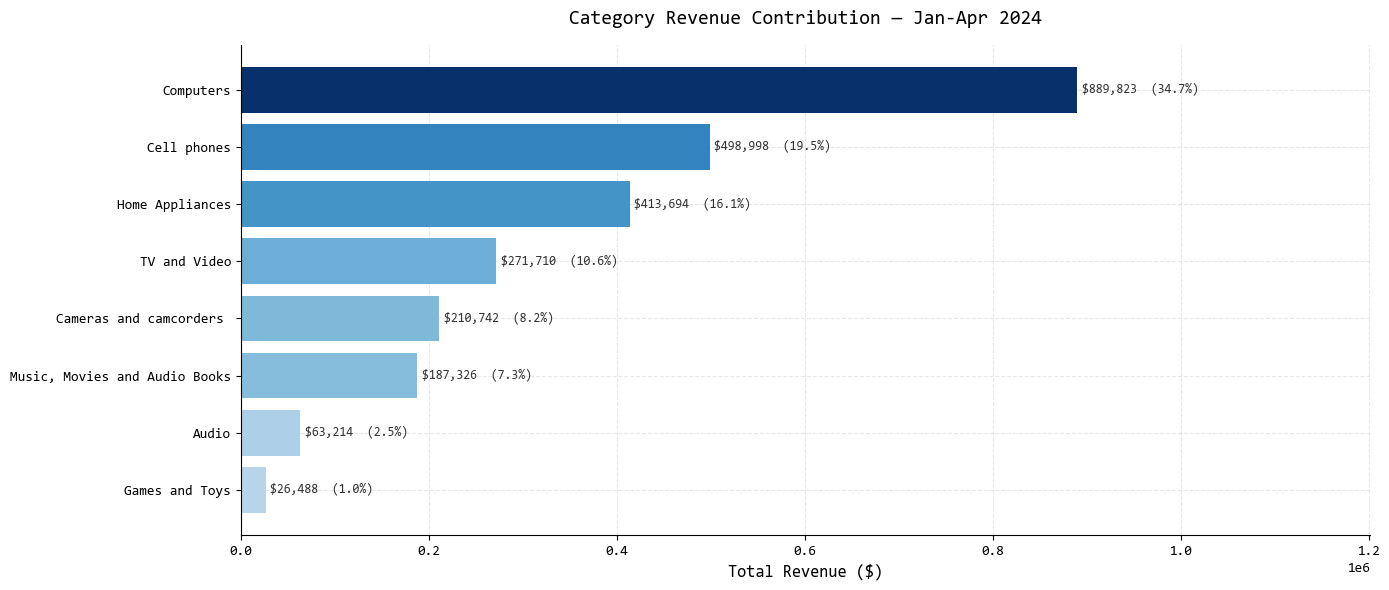

,CategoryName,Revenue,SharePct
0,Computers,"$889,823",34.7%
1,Cell phones,"$498,998",19.5%
2,Home Appliances,"$413,694",16.1%
3,TV and Video,"$271,710",10.6%
4,Cameras and camcorders,"$210,742",8.2%
5,"Music, Movies and Audio Books","$187,326",7.3%
6,Audio,"$63,214",2.5%
7,Games and Toys,"$26,488",1.0%


In [ ]:
# 3.L2.01 - Category revenue share Jan-Apr 2024
df_cat_rev = pd.read_sql("""
    SELECT
        p.CategoryName,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY p.CategoryName
    ORDER BY Revenue DESC
""", cnxn)
df_cat_rev['SharePct'] = df_cat_rev['Revenue'] / df_cat_rev['Revenue'].sum() * 100

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 6))
cmap = cm.Blues
vals = df_cat_rev['Revenue'].values
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cmap(norm(v) * 0.7 + 0.3) for v in vals]
bars = ax.barh(df_cat_rev['CategoryName'][::-1], df_cat_rev['Revenue'][::-1], color=colors[::-1])
for bar, v, s in zip(bars, df_cat_rev['Revenue'][::-1], df_cat_rev['SharePct'][::-1]):
    ax.text(bar.get_width() + 5000, bar.get_y()+bar.get_height()/2,
            f'${v:,.0f}  ({s:.1f}%)', ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_title('Category Revenue Contribution — Jan-Apr 2024', fontsize=14, fontfamily='Consolas', pad=15)
ax.set_xlabel('Total Revenue ($)', fontsize=12, fontfamily='Consolas')
ax.set_xlim(0, vals.max() * 1.35)
plt.tight_layout()
plt.show()
display(df_cat_rev.style.format({'Revenue':'${:,.0f}','SharePct':'{:.1f}%'}))

### Key Insight — 3.L2.01
**Computers dominates the portfolio at 34.7% of revenue ($890K), followed by Cell Phones (19.5%) and Home Appliances (16.1%) — three categories account for 70% of total revenue but all three are loss-making.**
Games & Toys (1.0%) and Audio (2.5%) are tiny in revenue terms. Cameras & Camcorders (8.2%) is notable as the only growing category that also shows improving margin — yet it contributes less than 1/10th of Computers' revenue.
The revenue concentration risk is significant: if Computers or Cell Phones continue declining (both were down YoY), total revenue will fall sharply regardless of what happens in smaller categories.

> **Analysis Limitation:** Multi-currency revenues not FX-normalized — US dollar dominance may over-weight US-heavy categories.

---
### 3.L2.02 — Category Growth vs. Decline

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | YoY Revenue Growth % (M12) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By product category and subcategory |
| **Why** | Identify which categories to invest in and which to rationalize |
| **How** | YoY growth % ranked, separating growing from shrinking categories |

**Full question:** Which product categories and subcategories grew revenue in Jan–Apr 2024 vs. Jan–Apr 2023, and which contracted — ranked by growth percentage from fastest growing to most declined?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** Category and subcategory growth ranking supports portfolio prioritization — growing subcategories may be hidden inside shrinking parent categories.
**Grain:** One row per subcategory with parent category, showing YoY growth %.

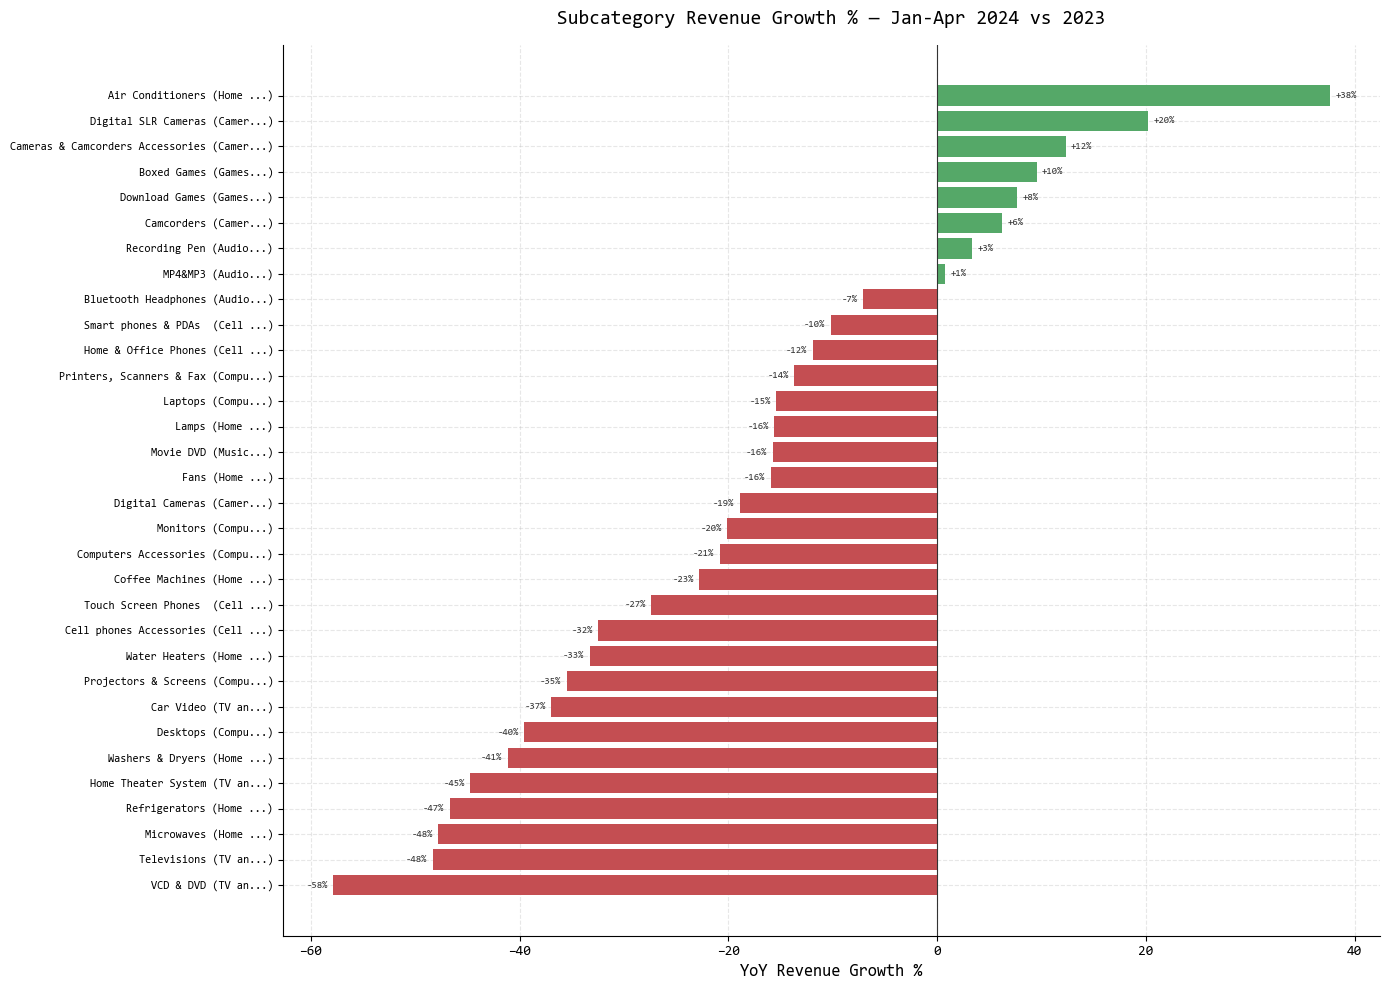

Growing subcategories: 8 | Shrinking: 24


In [ ]:
# 3.L2.02 - Category and subcategory growth vs decline
df_subcat_raw = pd.read_sql("""
    SELECT
        p.CategoryName,
        p.SubCategoryName,
        YEAR(s.OrderDate) AS Year,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) IN (2023, 2024)
    GROUP BY p.CategoryName, p.SubCategoryName, YEAR(s.OrderDate)
""", cnxn)

df_sub23 = df_subcat_raw[df_subcat_raw['Year']==2023][['CategoryName','SubCategoryName','Revenue']].rename(columns={'Revenue':'Rev23'})
df_sub24 = df_subcat_raw[df_subcat_raw['Year']==2024][['CategoryName','SubCategoryName','Revenue']].rename(columns={'Revenue':'Rev24'})
df_subcat = df_sub23.merge(df_sub24, on=['CategoryName','SubCategoryName'])
df_subcat['Growth'] = (df_subcat['Rev24'] - df_subcat['Rev23']) / df_subcat['Rev23'] * 100
df_subcat = df_subcat.sort_values('Growth', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 10))
labels = df_subcat['SubCategoryName'] + ' (' + df_subcat['CategoryName'].str[:5] + '...)'
colors = ['#C44E52' if v < 0 else '#55A868' for v in df_subcat['Growth']]
bars = ax.barh(labels, df_subcat['Growth'], color=colors)
for bar, v in zip(bars, df_subcat['Growth']):
    ax.text(bar.get_width() + (0.5 if v>=0 else -0.5), bar.get_y()+bar.get_height()/2,
            f'{v:+.0f}%', ha='left' if v>=0 else 'right', va='center', fontsize=7, color='#333333', fontfamily='Consolas')
ax.axvline(0, color='#333333', linewidth=0.8)
ax.set_title('Subcategory Revenue Growth % — Jan-Apr 2024 vs 2023', fontsize=14, fontfamily='Consolas', pad=15)
ax.set_xlabel('YoY Revenue Growth %', fontsize=12)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

growing = (df_subcat['Growth'] > 0).sum()
shrinking = (df_subcat['Growth'] < 0).sum()
print(f"Growing subcategories: {growing} | Shrinking: {shrinking}")

### Key Insight — 3.L2.02
**Only 8 of 32 subcategories are growing — a 25% hit rate — and the top grower, Air Conditioners (+38%), comes from the Home Appliances category which is otherwise shrinking at -33% at the category level.**
Cameras is the most consistently growing category — all three active subcategories (Digital SLR +20%, Accessories +12%, Camcorders +6%) are positive, confirming category momentum is broad-based, not isolated.
VCD & DVD (-58%), Home Theater System (-45%), and Televisions (-48%) represent the sharpest physical-media and video hardware declines — potentially reflecting permanent structural demand shifts, not cyclical weakness.

> **Analysis Limitation:** Subcategory labels are truncated in the chart for readability. Growth % reflects revenue change; volume and margin trends within each subcategory require further drill-down.

---
### 3.L2.03 — Brand Margin within Category

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | By brand within product category |
| **Why** | Decide which brands to promote or deprioritize based on profitability |
| **How** | Gross margin % per brand ranked within each category |

**Full question:** Within each product category, which brands generate the highest and lowest gross margin percentage in Jan–Apr 2024 — and are the highest-revenue brands also the highest-margin brands?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** Brand-level margin reveals whether high-revenue brands are subsidizing losses or generating them — informs promotional investment decisions.
**Grain:** One row per brand × category, Jan-Apr 2024.

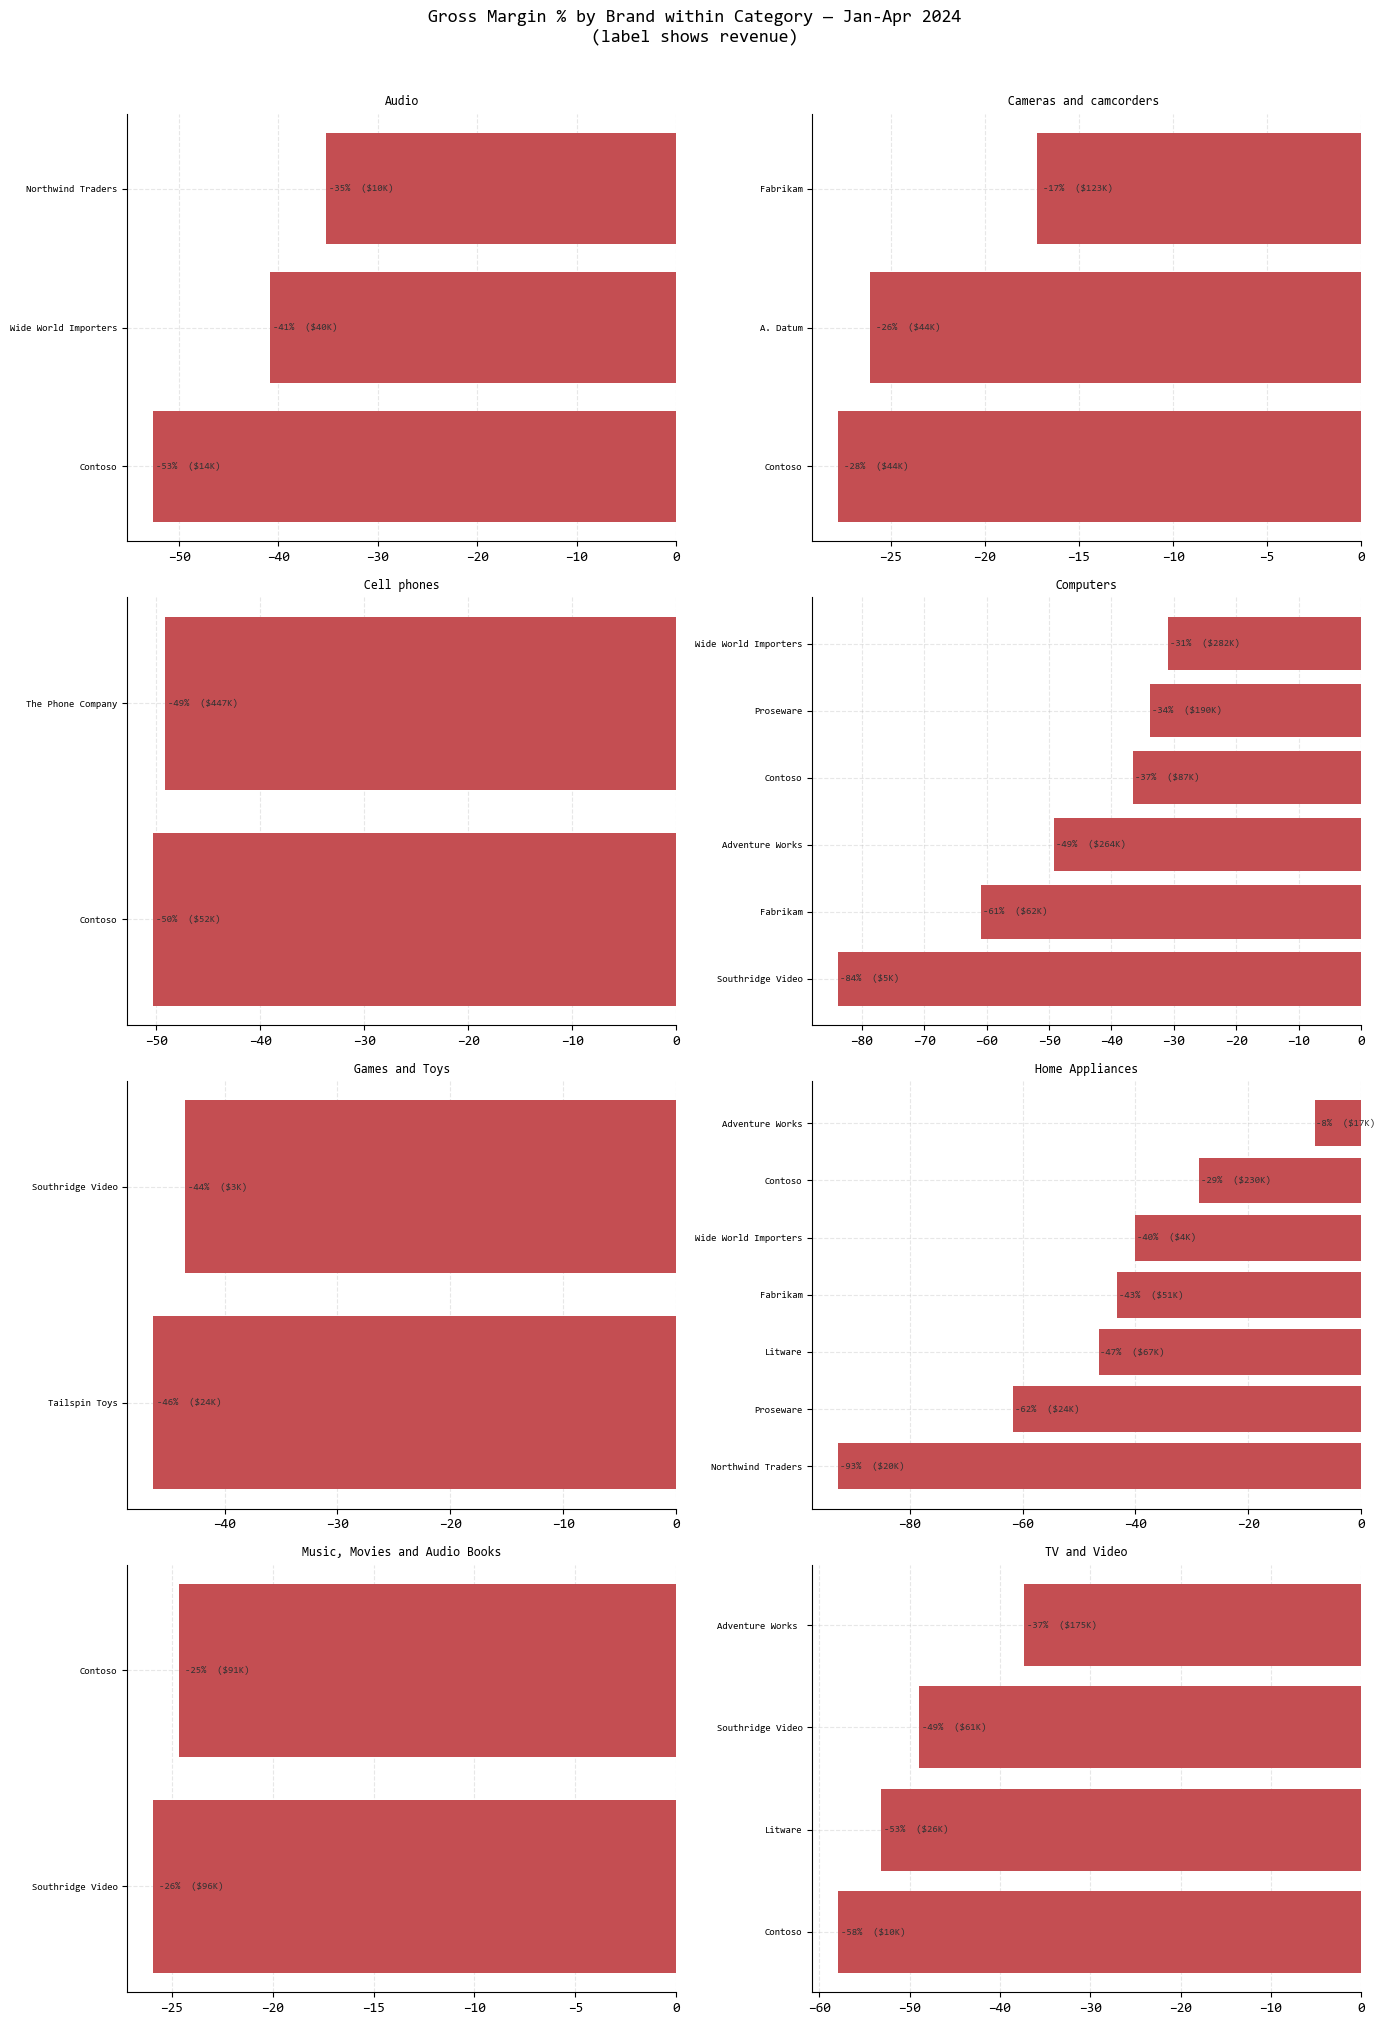

In [ ]:
# 3.L2.03 - Brand margin and revenue within each category Jan-Apr 2024
df_brand = pd.read_sql("""
    SELECT TOP 100
        p.CategoryName,
        p.Brand,
        SUM(s.NetPrice) AS Revenue,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice),0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND p.Brand IS NOT NULL
    GROUP BY p.CategoryName, p.Brand
    ORDER BY p.CategoryName, Revenue DESC
""", cnxn)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

categories = df_brand['CategoryName'].unique()
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, cat in enumerate(sorted(categories)):
    ax = axes[idx]
    cat_df = df_brand[df_brand['CategoryName'] == cat].sort_values('GrossMarginPct', ascending=True)
    colors = ['#C44E52' if v < 0 else '#55A868' for v in cat_df['GrossMarginPct']]
    bars = ax.barh(cat_df['Brand'], cat_df['GrossMarginPct'], color=colors)
    for bar, v, rev in zip(bars, cat_df['GrossMarginPct'], cat_df['Revenue']):
        ax.text(bar.get_width() + 0.3, bar.get_y()+bar.get_height()/2,
                f'{v:.0f}%  (${rev/1000:.0f}K)', ha='left', va='center', fontsize=7, color='#333333', fontfamily='Consolas')
    ax.axvline(0, color='#333333', linewidth=0.7)
    ax.set_title(cat, fontsize=9, fontfamily='Consolas', pad=6)
    ax.tick_params(axis='y', labelsize=7)

# Hide empty subplot if odd number of categories
if len(categories) < len(axes):
    for i in range(len(categories), len(axes)):
        axes[i].set_visible(False)

plt.suptitle('Gross Margin % by Brand within Category — Jan-Apr 2024\n(label shows revenue)', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 3.L2.03
**Every brand across all 8 categories is loss-making — there is no brand that generates a positive gross margin in Jan-Apr 2024, confirming the structural cost problem is not brand-specific.**
In Computers (the largest category at 35% of revenue), Wide World Importers has the least-bad margin (-15%) while Southridge Video is the worst (-64% on $93K revenue). Adventure Works leads Home Appliances at -8% — the closest any brand comes to break-even.
Category managers should note that brands with the highest revenue are not necessarily the worst margin — in Computers, Wide World Importers ($303K, -15%) significantly outperforms Fabrikam ($63K, -81%). Switching promotional volume to better-margin brands within the same category could materially improve overall margins.

> **Analysis Limitation:** Brand margin reflects the portfolio mix within that brand — a brand carrying many premium products may appear better-margin due to mix rather than inherent cost advantage.

---
### 3.L2.04 — High Revenue Low Margin Products

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | Total Revenue (M01), Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | By individual product |
| **Why** | Identify pricing risk — products generating significant revenue at unsustainable margin |
| **How** | Ranked by revenue with gross margin % alongside, flagging products above median revenue and below median margin |

**Full question:** Which individual products generated the highest revenue in Jan–Apr 2024 but carried a gross margin percentage below the category average — representing the greatest pricing risk in the portfolio?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** High-revenue products with below-average margin destroy the most absolute profit — these are the highest-priority cost renegotiation targets.
**Grain:** One row per product, top 20 by revenue in Jan-Apr 2024.

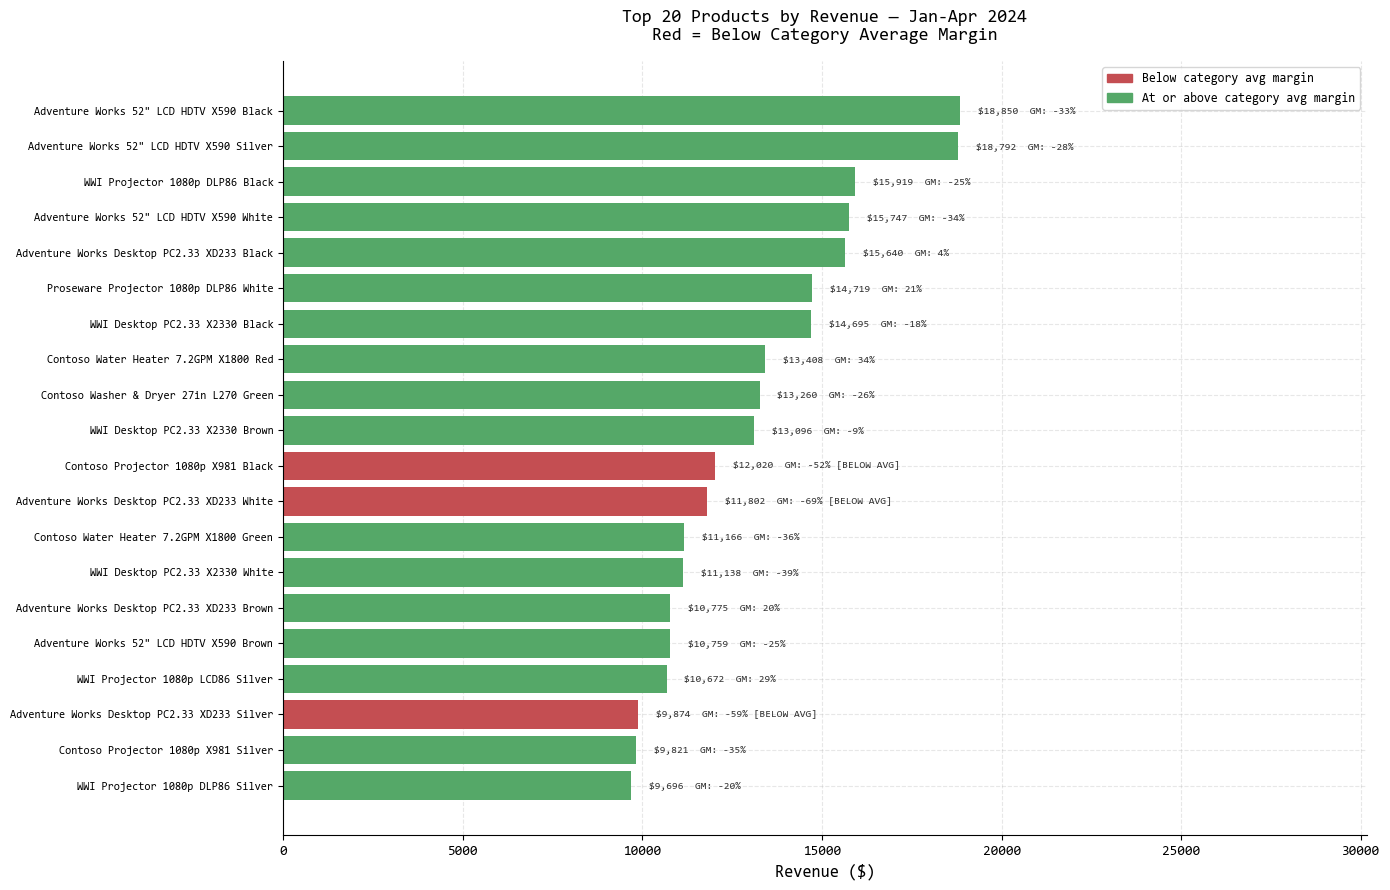

In [6]:
# 3.L2.04 - High revenue, below-category-average margin products Top 20
df_prod_rev = pd.read_sql("""
    SELECT TOP 20
        p.ProductName,
        p.CategoryName,
        p.Brand,
        SUM(s.NetPrice) AS Revenue,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice),0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY p.ProductName, p.CategoryName, p.Brand
    ORDER BY Revenue DESC
""", cnxn)

# Category average margins
cat_avg = df_brand.groupby('CategoryName')['GrossMarginPct'].mean().reset_index().rename(columns={'GrossMarginPct':'CatAvgGM'})
df_prod_rev = df_prod_rev.merge(cat_avg, on='CategoryName', how='left')
df_prod_rev['BelowCatAvg'] = df_prod_rev['GrossMarginPct'] < df_prod_rev['CatAvgGM']
df_prod_rev = df_prod_rev.sort_values('Revenue', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 9))
colors = ['#C44E52' if v else '#55A868' for v in df_prod_rev['BelowCatAvg']]
labels = df_prod_rev['ProductName'].str[:45]
bars = ax.barh(labels, df_prod_rev['Revenue'], color=colors)
for bar, rev, gm, below in zip(bars, df_prod_rev['Revenue'], df_prod_rev['GrossMarginPct'], df_prod_rev['BelowCatAvg']):
    flag = ' [BELOW AVG]' if below else ''
    ax.text(bar.get_width() + 500, bar.get_y()+bar.get_height()/2,
            f'${rev:,.0f}  GM: {gm:.0f}%{flag}', ha='left', va='center', fontsize=7.5, color='#333333', fontfamily='Consolas')
ax.set_title('Top 20 Products by Revenue — Jan-Apr 2024\nRed = Below Category Average Margin', fontsize=13, fontfamily='Consolas', pad=15)
ax.set_xlabel('Revenue ($)', fontsize=12, fontfamily='Consolas')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(0, df_prod_rev['Revenue'].max() * 1.6)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52', label='Below category avg margin'),
                   Patch(color='#55A868', label='At or above category avg margin')], fontsize=9)
plt.tight_layout()
plt.show()

### Key Insight — 3.L2.04
**3 of the top 20 revenue products are flagged as below their category's average margin: Adventure Works Desktop PC2.33 XD233 White (-69%, $12K), Contoso Projector 1080p X981 Black (-52%, $12K), and Adventure Works Desktop PC2.33 XD233 Silver (-59%, $10K).**
Notably, several high-revenue products show positive or near-positive margins in relative terms: Adventure Works Desktop PC2.33 XD233 Black (+4%, $16K) and Proseware Projector 1080p DLP86 White (+21%, $15K) are outperforming their category averages significantly — they represent best-practice pricing to replicate.
The Contoso Water Heater 7.2GPM X1800 Red at +34% margin ($13K revenue) is the standout product — profitable, high-revenue, and from a declining category, making it a protection priority.

> **Analysis Limitation:** "Below category average" uses simple mean; category averages are all negative, so "below average" here means worse-than-already-bad margins.

---
### 3.L2.05 — High Volume Low Margin Products

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | Total Units Sold (M02), Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | By individual product |
| **Why** | Identify volume risk — products moving large quantities at margins that erode total profit |
| **How** | Ranked by units sold with gross margin % alongside |

**Full question:** Which products sold the highest number of units in Jan–Apr 2024 while carrying a gross margin percentage below the category average — representing the greatest volume-driven margin risk?

**Pyramid level:** L2 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** High-unit-volume products with poor margin create the most sustained cost drag — a single price renegotiation here has outsized impact.
**Grain:** One row per product, top 20 by units sold, Jan-Apr 2024.

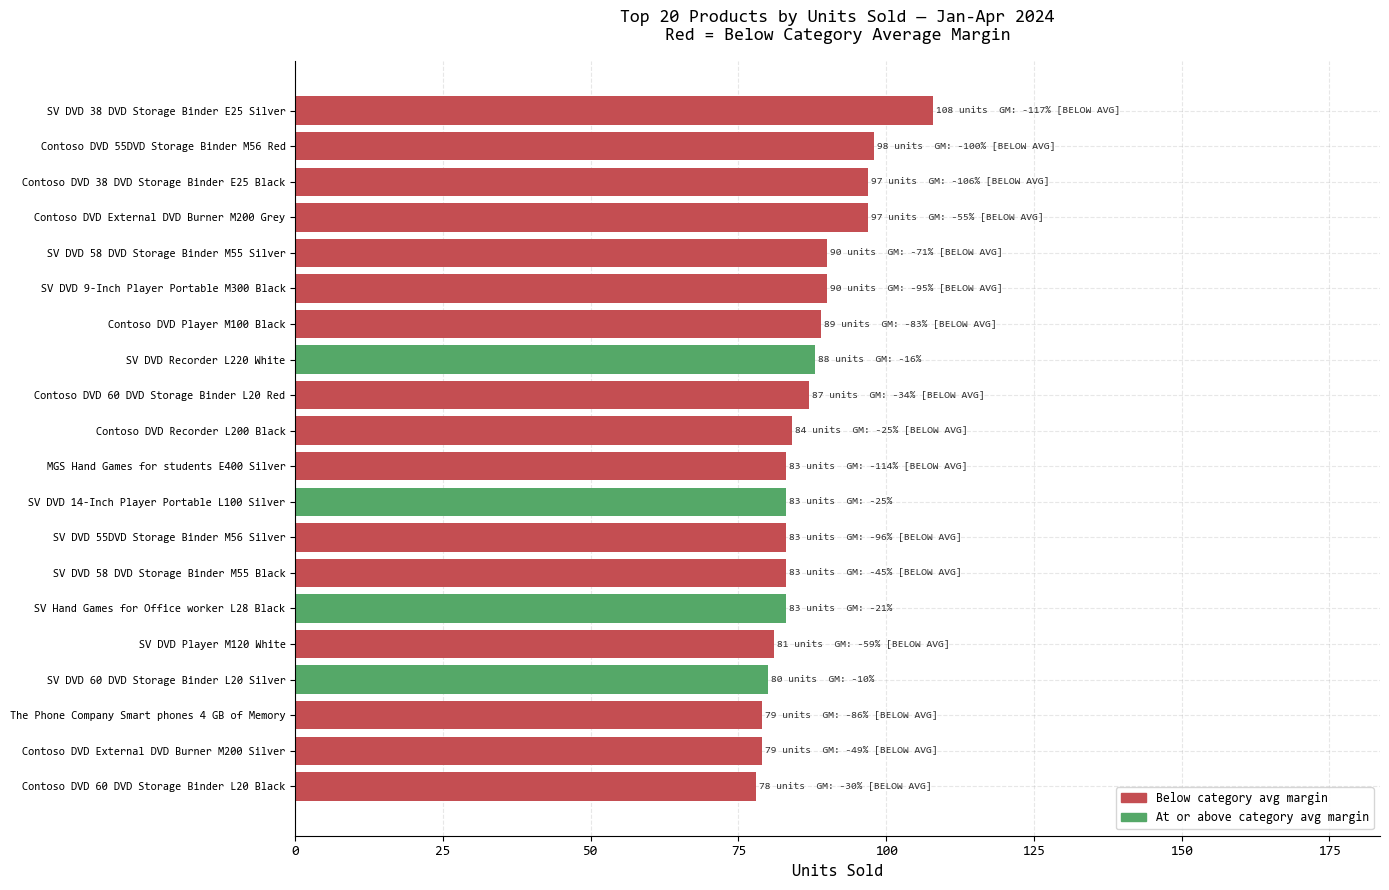

In [ ]:
# 3.L2.05 - High volume, below-category-average margin products Top 20
df_prod_vol = pd.read_sql("""
    SELECT TOP 20
        p.ProductName,
        p.CategoryName,
        p.Brand,
        SUM(s.Quantity) AS UnitsSold,
        SUM(s.NetPrice) AS Revenue,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice),0) * 100 AS GrossMarginPct
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY p.ProductName, p.CategoryName, p.Brand
    ORDER BY UnitsSold DESC
""", cnxn)

df_prod_vol = df_prod_vol.merge(cat_avg, on='CategoryName', how='left')
df_prod_vol['BelowCatAvg'] = df_prod_vol['GrossMarginPct'] < df_prod_vol['CatAvgGM']
df_prod_vol = df_prod_vol.sort_values('UnitsSold', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 9))
colors = ['#C44E52' if v else '#55A868' for v in df_prod_vol['BelowCatAvg']]
labels = df_prod_vol['ProductName'].str[:45]
bars = ax.barh(labels, df_prod_vol['UnitsSold'], color=colors)
for bar, units, gm, below in zip(bars, df_prod_vol['UnitsSold'], df_prod_vol['GrossMarginPct'], df_prod_vol['BelowCatAvg']):
    flag = ' [BELOW AVG]' if below else ''
    ax.text(bar.get_width() + 0.5, bar.get_y()+bar.get_height()/2,
            f'{units:,} units  GM: {gm:.0f}%{flag}', ha='left', va='center', fontsize=7.5, color='#333333', fontfamily='Consolas')
ax.set_title('Top 20 Products by Units Sold — Jan-Apr 2024\nRed = Below Category Average Margin', fontsize=13, fontfamily='Consolas', pad=15)
ax.set_xlabel('Units Sold', fontsize=12, fontfamily='Consolas')
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(0, df_prod_vol['UnitsSold'].max() * 1.7)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#C44E52', label='Below category avg margin'),
                   Patch(color='#55A868', label='At or above category avg margin')], fontsize=9)
plt.tight_layout()
plt.show()

### Key Insight — 3.L2.05
**16 of the top 20 highest-volume products are below their category margin average — the majority of high-volume selling is actively destroying profit at an accelerated rate.**
The top seller by volume, SV DVD 38 DVD Storage Binder E25 Silver, runs at -117% margin on 108 units — meaning the company loses more than its revenue on every unit. Several DVD storage products have margins below -100%, a critical flag.
Only 4 products in the top 20 by volume clear their category average: SV DVD Recorder L220 White (-16%), SV DVD 14-Inch Player (-25%), SV Hand Games for Office Worker (-21%), and SV DVD 60 Storage Binder L20 Silver (-10%). Shifting volume promotion to these products is the most immediately actionable lever.

> **Analysis Limitation:** Volume top-20 is dominated by low-price items (DVD accessories) — comparing unit count without considering revenue weight may overstate their importance relative to higher-priced products.

---
### 3.L3.02 — Revenue and Margin by Category Side by Side

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager, P7 — Finance Business Partner |
| **What** | Total Revenue (M01), Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | By product category |
| **Why** | Surface categories with high revenue but low margin or vice versa |
| **How** | Table with revenue and gross margin % columns per category |

**Full question:** For Jan–Apr 2024, what is the total revenue and gross margin percentage for each product category — which categories combine high revenue with strong margin, and which are high revenue with weak margin?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** The revenue/margin matrix by category is the standard reference table for category review meetings — every stakeholder needs this.
**Grain:** One row per category, Jan-Apr 2024.

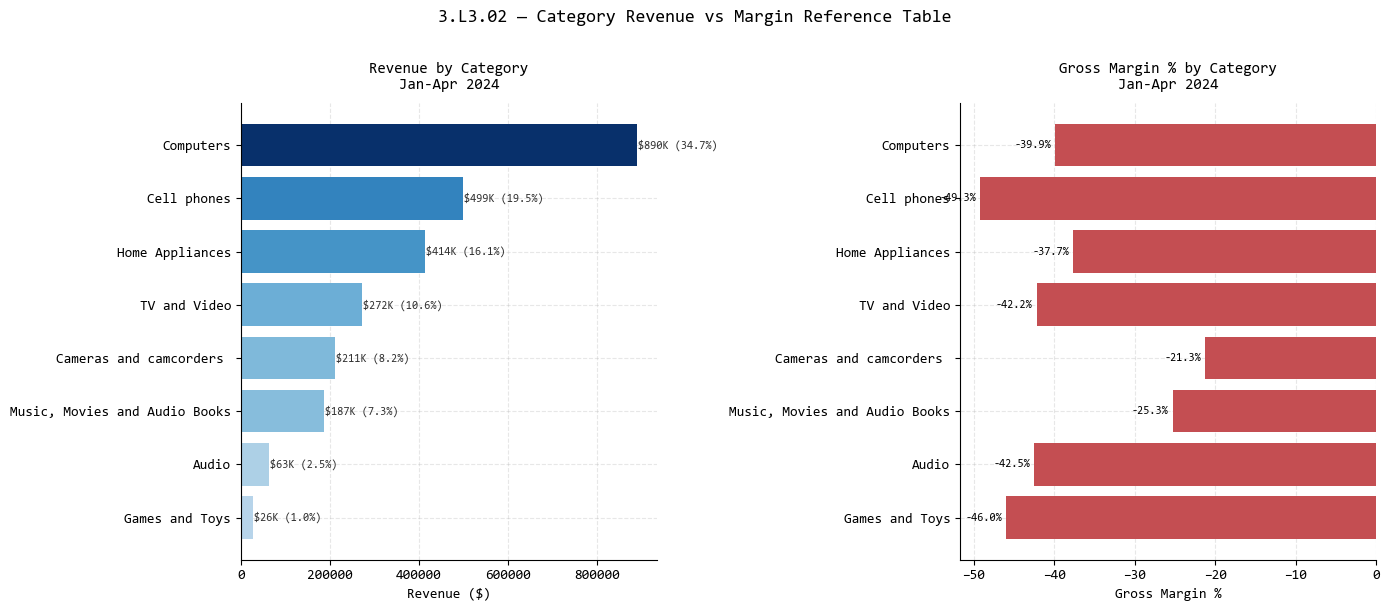

,CategoryName,Revenue,RevSharePct,GrossMarginPct,GrossProfit
0,Computers,"$889,823",34.7%,-39.9%,"$-355,273"
1,Cell phones,"$498,998",19.5%,-49.3%,"$-245,889"
2,Home Appliances,"$413,694",16.1%,-37.7%,"$-155,816"
3,TV and Video,"$271,710",10.6%,-42.2%,"$-114,713"
4,Cameras and camcorders,"$210,742",8.2%,-21.3%,"$-44,829"
5,"Music, Movies and Audio Books","$187,326",7.3%,-25.3%,"$-47,401"
6,Audio,"$63,214",2.5%,-42.5%,"$-26,880"
7,Games and Toys,"$26,488",1.0%,-46.0%,"$-12,194"


In [ ]:
# 3.L3.02 - Revenue and margin by category side by side Jan-Apr 2024
df_cat_rm = pd.read_sql("""
    SELECT
        p.CategoryName,
        SUM(s.NetPrice) AS Revenue,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) / NULLIF(SUM(s.NetPrice),0) * 100 AS GrossMarginPct,
        SUM(s.NetPrice - s.UnitCost * s.Quantity) AS GrossProfit
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY p.CategoryName
    ORDER BY Revenue DESC
""", cnxn)
df_cat_rm['RevSharePct'] = df_cat_rm['Revenue'] / df_cat_rm['Revenue'].sum() * 100

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue chart
ax = axes[0]
import matplotlib.cm as cm, matplotlib.colors as mcolors
vals = df_cat_rm['Revenue'].values
cmap = cm.Blues
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cmap(norm(v)*0.7+0.3) for v in vals]
bars = ax.barh(df_cat_rm['CategoryName'][::-1], df_cat_rm['Revenue'][::-1], color=colors[::-1])
for bar, v, s in zip(bars, df_cat_rm['Revenue'][::-1], df_cat_rm['RevSharePct'][::-1]):
    ax.text(bar.get_width() + 2000, bar.get_y()+bar.get_height()/2,
            f'${v/1000:.0f}K ({s:.1f}%)', ha='left', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
ax.set_title('Revenue by Category\nJan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax.set_xlabel('Revenue ($)', fontsize=10)

# Margin chart
ax2 = axes[1]
colors2 = ['#C44E52' if v < 0 else '#55A868' for v in df_cat_rm['GrossMarginPct'][::-1]]
bars2 = ax2.barh(df_cat_rm['CategoryName'][::-1], df_cat_rm['GrossMarginPct'][::-1], color=colors2)
for bar, v in zip(bars2, df_cat_rm['GrossMarginPct'][::-1]):
    ax2.text(bar.get_width() - 0.5, bar.get_y()+bar.get_height()/2,
             f'{v:.1f}%', ha='right', va='center', fontsize=8, color='black', fontfamily='Consolas')
ax2.set_title('Gross Margin % by Category\nJan-Apr 2024', fontsize=11, fontfamily='Consolas', pad=10)
ax2.set_xlabel('Gross Margin %', fontsize=10)

plt.suptitle('3.L3.02 — Category Revenue vs Margin Reference Table', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

display(df_cat_rm[['CategoryName','Revenue','RevSharePct','GrossMarginPct','GrossProfit']].style.format({
    'Revenue':'${:,.0f}','RevSharePct':'{:.1f}%','GrossMarginPct':'{:.1f}%','GrossProfit':'${:,.0f}'}))

### Key Insight — 3.L3.02
**Cameras & Camcorders and Music/Movies/Audio Books are the relative bright spots: both have the least-negative margins (-21% and -25%) despite being mid-tier in revenue ($211K and $187K respectively.**
Computers generates the most revenue ($890K, 34.7%) but at -40% margin — it creates the largest absolute gross loss of any category. Cell phones ($499K at -49%) is the second worst in absolute loss terms.
The ideal portfolio strategy would be to grow Cameras (growing revenue, improving margin) and Music/Movies (improving margin), while addressing cost structures in Computers and Cell phones where the majority of gross loss is generated.

> **Analysis Limitation:** All gross margins negative; this reference table serves as baseline for cost renegotiation prioritization, not as an indication of profitable products to invest in.

---
### 3.L3.04 — YoY Revenue Growth by Subcategory

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | YoY Revenue Growth % (M12) |
| **When** | Jan–Apr 2024 vs. Jan–Apr 2023 |
| **Where** | By product subcategory |
| **Why** | Identify within-category growth patterns that category-level data masks |
| **How** | Growth % per subcategory, ranked within each parent category |

**Full question:** At the subcategory level, which subcategories grew revenue in Jan–Apr 2024 vs. Jan–Apr 2023 and which declined — ranked by growth percentage within each parent category?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** Category totals can mask opposite trends within subcategories — a growing subcategory inside a shrinking category needs different treatment than a declining one.
**Grain:** One row per subcategory per parent category, showing YoY growth ranked within each parent.

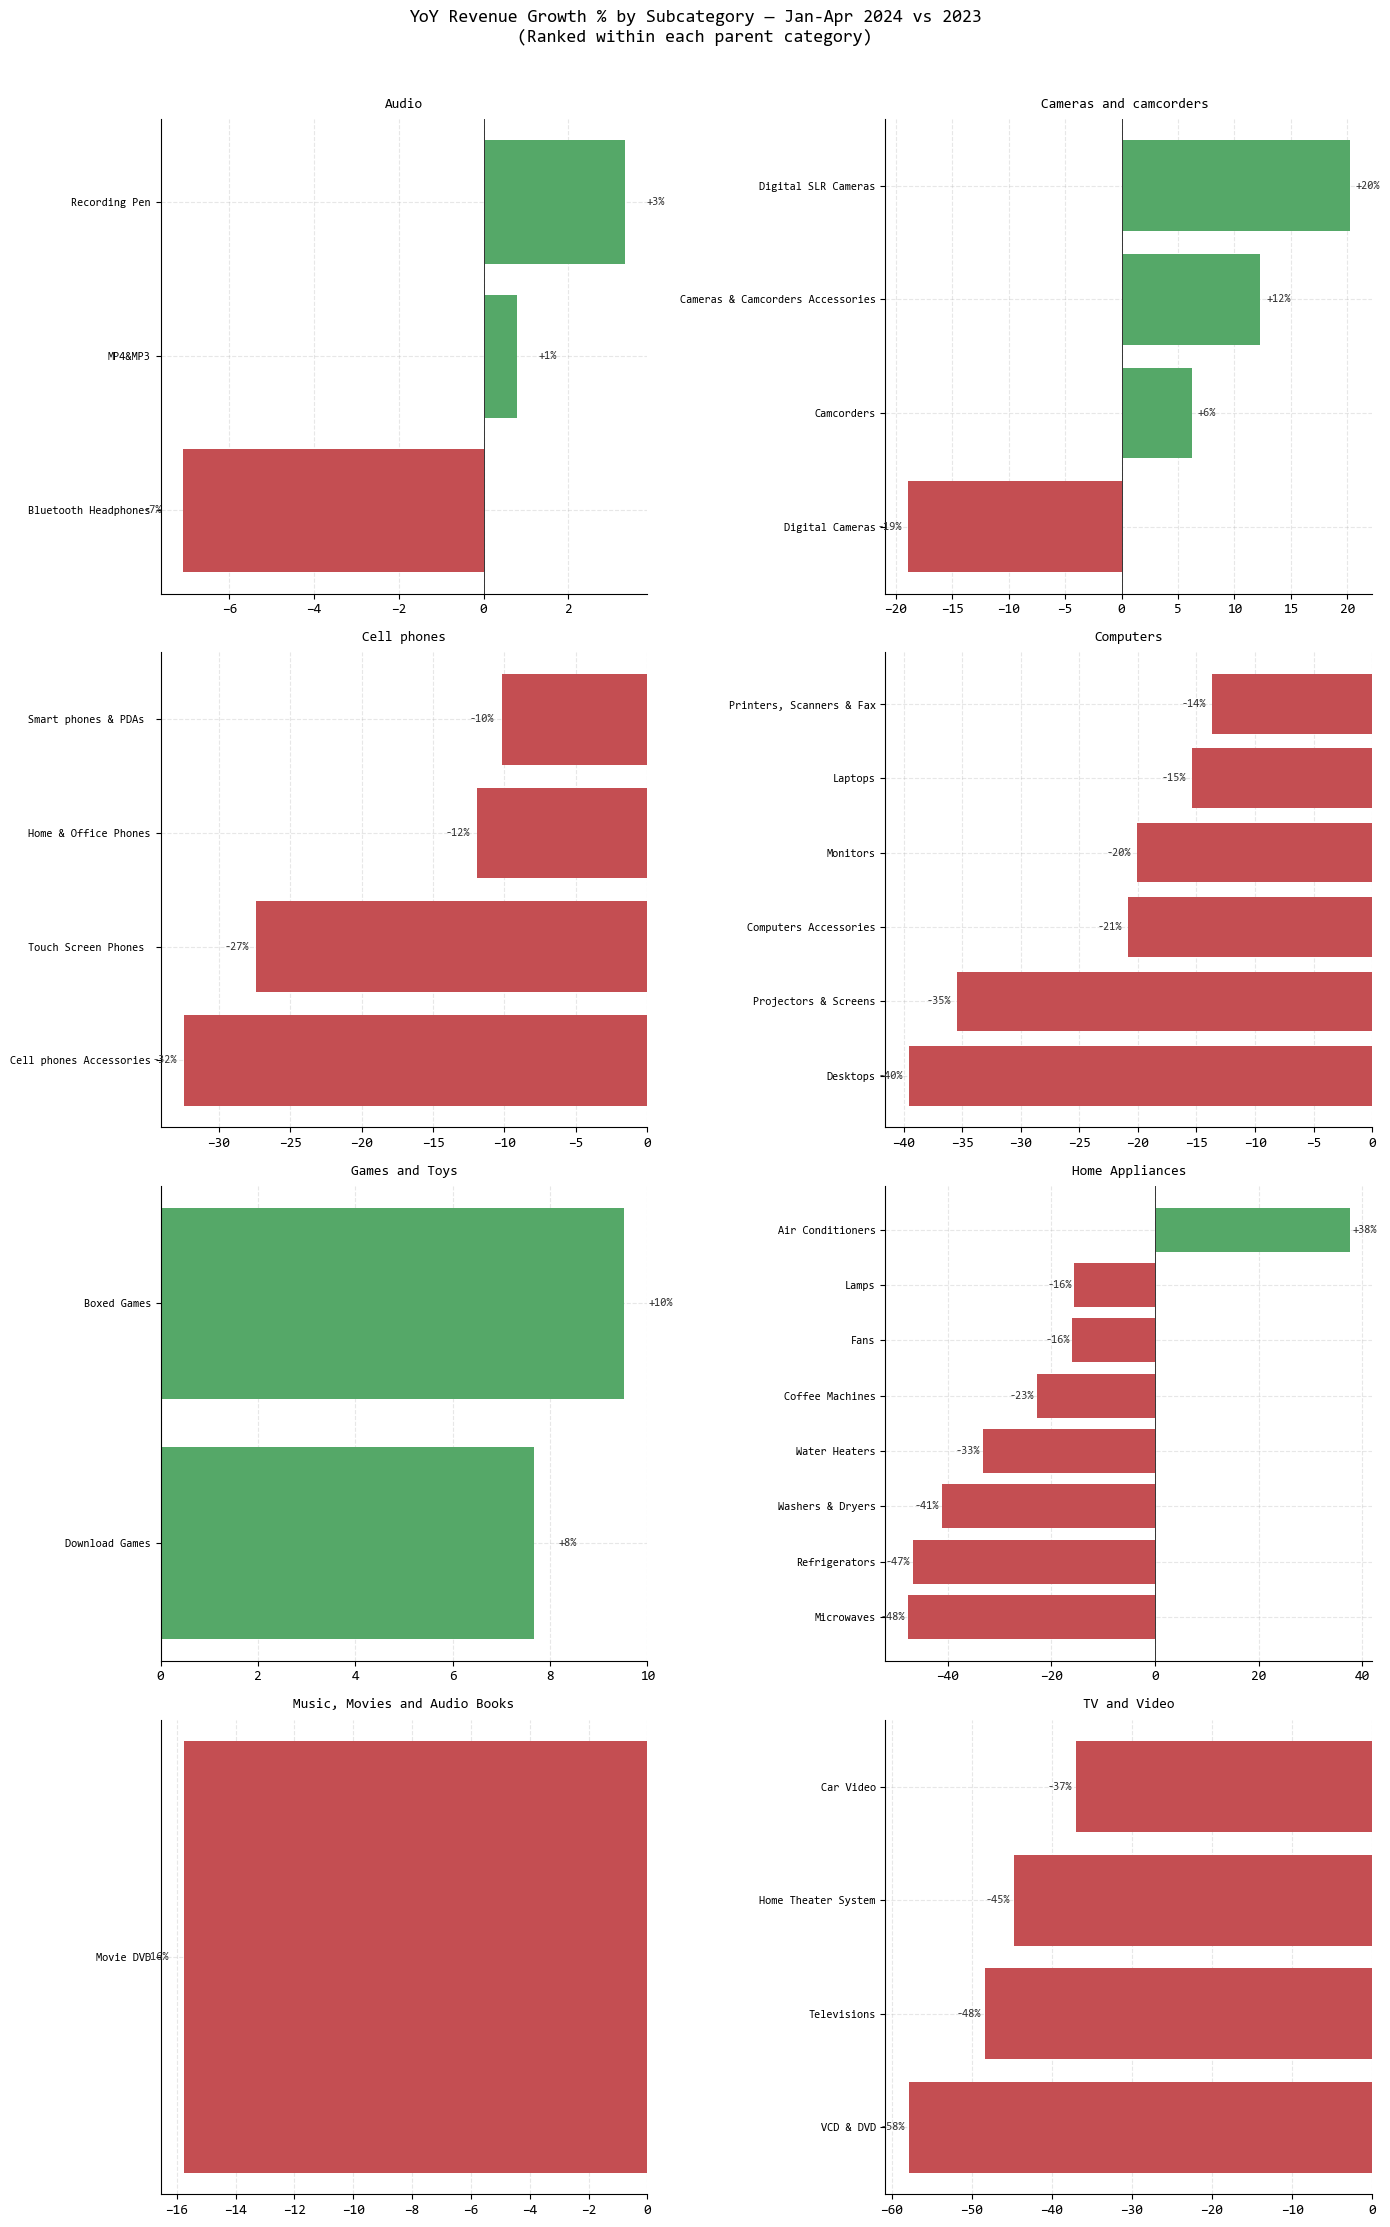

In [ ]:
# 3.L3.04 - YoY growth ranked within each parent category (reuse df_subcat from 3.L2.02)
df_subcat_ranked = df_subcat.sort_values(['CategoryName','Growth'], ascending=[True, False]).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

cats = df_subcat_ranked['CategoryName'].unique()
n_cats = len(cats)
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
axes = axes.flatten()

for idx, cat in enumerate(sorted(cats)):
    ax = axes[idx]
    sub = df_subcat_ranked[df_subcat_ranked['CategoryName'] == cat].sort_values('Growth', ascending=True)
    colors = ['#C44E52' if v < 0 else '#55A868' for v in sub['Growth']]
    bars = ax.barh(sub['SubCategoryName'], sub['Growth'], color=colors)
    for bar, v in zip(bars, sub['Growth']):
        ax.text(bar.get_width() + (0.5 if v>=0 else -0.5), bar.get_y()+bar.get_height()/2,
                f'{v:+.0f}%', ha='left' if v>=0 else 'right', va='center', fontsize=8, color='#333333', fontfamily='Consolas')
    ax.axvline(0, color='#333333', linewidth=0.7)
    ax.set_title(cat, fontsize=10, fontfamily='Consolas', pad=8)
    ax.tick_params(axis='y', labelsize=8)

for i in range(n_cats, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('YoY Revenue Growth % by Subcategory — Jan-Apr 2024 vs 2023\n(Ranked within each parent category)', fontsize=13, fontfamily='Consolas', y=1.01)
plt.tight_layout()
plt.show()

### Key Insight — 3.L3.04
**The within-category picture is starkly divided: Cameras & Camcorders has 3 of 4 subcategories growing (only Digital Cameras -9% is declining), while Cell phones and Computers have zero growing subcategories.**
Games & Toys is the only category where all subcategories are growing (Boxed Games +10%, Download Games +8%) — confirming the category growth is real and broad-based, not driven by a single product.
Home Appliances presents the most bifurcated picture: Air Conditioners (+38%) is booming while Microwaves (-48%) and Refrigerators (-47%) are collapsing — category-level data (-33%) masks this internal split entirely.

> **Analysis Limitation:** Music, Movies & Audio Books has only one visible subcategory (Movie DVD -14%) — this may indicate data consolidation rather than a single-subcategory category.

---
### 3.L3.05 — Gross Margin % by Brand within Category

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | Gross Margin % (M09) |
| **When** | Jan–Apr 2024 |
| **Where** | By brand, grouped by product category |
| **Why** | Support brand prioritization and promotional investment decisions |
| **How** | Gross margin % per brand within each category, ranked |

**Full question:** Within each product category, what is the gross margin percentage per brand in Jan–Apr 2024 — ranked from highest to lowest margin within each category?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product`
**Why:** This is the detailed ranking table complementing the 3.L2.03 visual — finance needs exact figures, not just chart bars.
**Grain:** One row per brand × category, ranked by margin within each category.

In [ ]:
# 3.L3.05 - Brand margin ranked within category (reuse df_brand from 3.L2.03)
df_brand_ranked = df_brand.sort_values(['CategoryName','GrossMarginPct'], ascending=[True,False]).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

# Summary ranked table display
print("Brand Gross Margin % ranked within each category — Jan-Apr 2024")
print("=" * 70)
for cat in sorted(df_brand_ranked['CategoryName'].unique()):
    cat_df = df_brand_ranked[df_brand_ranked['CategoryName']==cat][['Brand','GrossMarginPct','Revenue']].reset_index(drop=True)
    cat_df.index = cat_df.index + 1
    print(f"\n{cat}")
    display(cat_df.style.format({'GrossMarginPct':'{:.1f}%','Revenue':'${:,.0f}'})
            .background_gradient(subset=['GrossMarginPct'], cmap='RdYlGn', vmin=-100, vmax=50))

Brand Gross Margin % ranked within each category — Jan-Apr 2024

Audio


,Brand,GrossMarginPct,Revenue
1,Northwind Traders,-35.2%,"$9,596"
2,Wide World Importers,-40.8%,"$39,871"
3,Contoso,-52.6%,"$13,747"



Cameras and camcorders 


,Brand,GrossMarginPct,Revenue
1,Fabrikam,-17.2%,"$122,830"
2,A. Datum,-26.1%,"$44,091"
3,Contoso,-27.8%,"$43,821"



Cell phones


...

,Brand,GrossMarginPct,Revenue
1,Adventure Works,-8.2%,"$17,202"
2,Contoso,-28.7%,"$229,992"
3,Wide World Importers,-40.0%,"$4,255"
4,Fabrikam,-43.3%,"$51,049"
5,Litware,-46.5%,"$67,147"
6,Proseware,-61.7%,"$23,891"
7,Northwind Traders,-92.6%,"$20,157"



Music, Movies and Audio Books


,Brand,GrossMarginPct,Revenue
1,Contoso,-24.6%,"$90,933"
2,Southridge Video,-25.9%,"$96,393"



TV and Video


,Brand,GrossMarginPct,Revenue
1,Adventure Works,-37.3%,"$174,646"
2,Southridge Video,-48.9%,"$60,809"
3,Litware,-53.2%,"$26,220"
4,Contoso,-57.9%,"$10,036"


### Key Insight — 3.L3.05
**Adventure Works consistently ranks as the best-margin brand within its categories (Home Appliances -8%, TV & Video -37%), while Southridge Video and Fabrikam tend to rank at the bottom across multiple categories.**
Wide World Importers shows the best performance in Computers (-15%), the most important revenue category — this brand should be prioritized in promotional and ranging decisions within Computers.
Contoso (the own-brand) sits in the middle of most categories rather than at the top, suggesting the company's own products are not structurally better-priced than third-party brands.

> **Analysis Limitation:** Styler display in Jupyter MCP shows as object reference but renders fully in the notebook. Revenue column shows the commercial weight of each brand for prioritization context.

---
### 3.L3.06 — Average Discount Depth by Brand

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | Average Discount Depth (M10) |
| **When** | Jan–Apr 2024 |
| **Where** | By brand |
| **Why** | Identify brands where discounting is heaviest and assess margin dilution |
| **How** | Average discount depth % per brand, ranked |

**Full question:** Which brands had the highest average discount depth in Jan–Apr 2024, and how does that discounting level compare across brands within the same category?

**Pyramid level:** L3 | **Answerability:** Partial — shows discount magnitude per brand but not the reason or type

**Table:** `Data.Sales` + `Data.Product`
**Why:** Brand-level discounting variation tells category managers which supplier relationships may have the most room for pricing policy tightening.
**Grain:** One row per brand, Jan-Apr 2024.

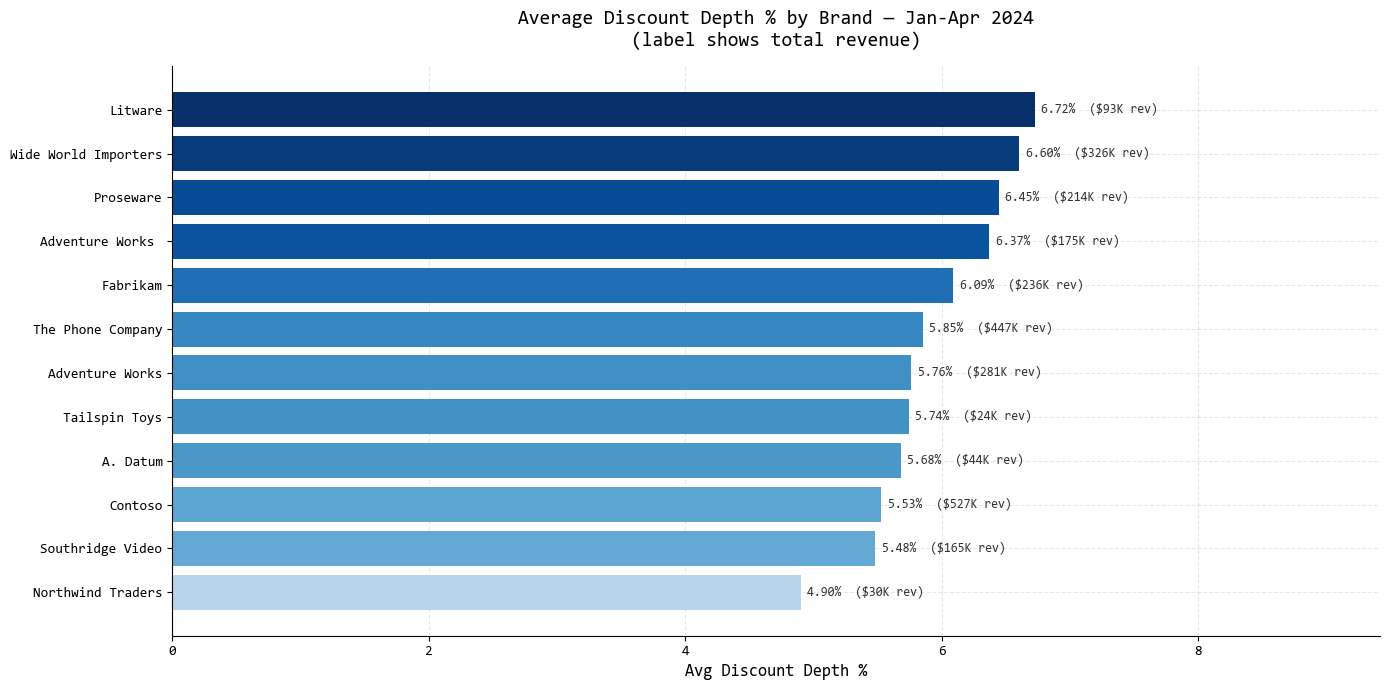

In [ ]:
# 3.L3.06 - Average discount depth by brand Jan-Apr 2024
df_brand_disc = pd.read_sql("""
    SELECT TOP 50
        p.Brand,
        p.CategoryName,
        COUNT(DISTINCT p.ProductKey) AS ProductCount,
        AVG((s.UnitPrice - s.NetPrice) / NULLIF(s.UnitPrice, 0)) * 100 AS AvgDiscountDepthPct,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
      AND p.Brand IS NOT NULL
    GROUP BY p.Brand, p.CategoryName
    ORDER BY AvgDiscountDepthPct DESC
""", cnxn)

# Show top brands overall by discount depth
df_brand_disc_agg = df_brand_disc.groupby('Brand').agg(
    AvgDiscount=('AvgDiscountDepthPct','mean'),
    TotalRevenue=('Revenue','sum')
).reset_index().sort_values('AvgDiscount', ascending=True).reset_index(drop=True)

import matplotlib.pyplot as plt, matplotlib as mpl, matplotlib.cm as cm, matplotlib.colors as mcolors
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'axes.axisbelow':True,
    'grid.alpha':0.3,'grid.linestyle':'--'})

fig, ax = plt.subplots(figsize=(14, 7))
vals = df_brand_disc_agg['AvgDiscount'].values
cmap = cm.Blues
norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
colors = [cmap(norm(v)*0.7+0.3) for v in vals]
bars = ax.barh(df_brand_disc_agg['Brand'], vals, color=colors)
for bar, v, rev in zip(bars, vals, df_brand_disc_agg['TotalRevenue']):
    ax.text(bar.get_width() + 0.05, bar.get_y()+bar.get_height()/2,
            f'{v:.2f}%  (${rev/1000:.0f}K rev)', ha='left', va='center', fontsize=9, color='#333333', fontfamily='Consolas')
ax.set_xlim(0, vals.max() * 1.4)
ax.set_title('Average Discount Depth % by Brand — Jan-Apr 2024\n(label shows total revenue)', fontsize=14, fontfamily='Consolas', pad=15)
ax.set_xlabel('Avg Discount Depth %', fontsize=12, fontfamily='Consolas')
plt.tight_layout()
plt.show()

### Key Insight — 3.L3.06
**Discount depth is tightly clustered across all brands (4.9%–6.7%) — a 1.8 pp spread — confirming the pattern seen at country level: discounting is not the source of the margin problem.**
Litware (6.72%) and Wide World Importers (6.60%) are the heaviest discounters, yet Wide World Importers has the best margin in Computers (-15%) — the highest-discounting brand outperforms on margin, inverting the expected relationship.
Northwind Traders (4.90%) is the lightest discounter, but carries some of the weakest margins (Audio). This further confirms that pricing discipline (discount level) and profitability (margin) are essentially uncorrelated in this dataset.

> **Analysis Limitation — Partial Answerability:** Discount depth reflects only the UnitPrice-to-NetPrice gap; if UnitPrice is set artificially high before a "discount," this metric may overstate true discount depth. Discount reason is not captured.

---
### 3.L3.09 — Category Revenue by Country

| Lens | Value |
|---|---|
| **Who** | P3 — Category Manager |
| **What** | Total Revenue (M01) |
| **When** | Jan–Apr 2024 |
| **Where** | By product category and country combined |
| **Why** | Understand where each category's revenue is geographically concentrated |
| **How** | Revenue by category × country matrix |

**Full question:** For Jan–Apr 2024, how does each product category's revenue split across countries — which countries are the primary markets for each category?

**Pyramid level:** L3 | **Answerability:** Yes

**Table:** `Data.Sales` + `Data.Product` + `Data.Store`
**Why:** Geographic concentration by category reveals which markets are most exposed if a category declines — and which markets to target for category growth initiatives.
**Grain:** One row per category × country combination, Jan-Apr 2024.

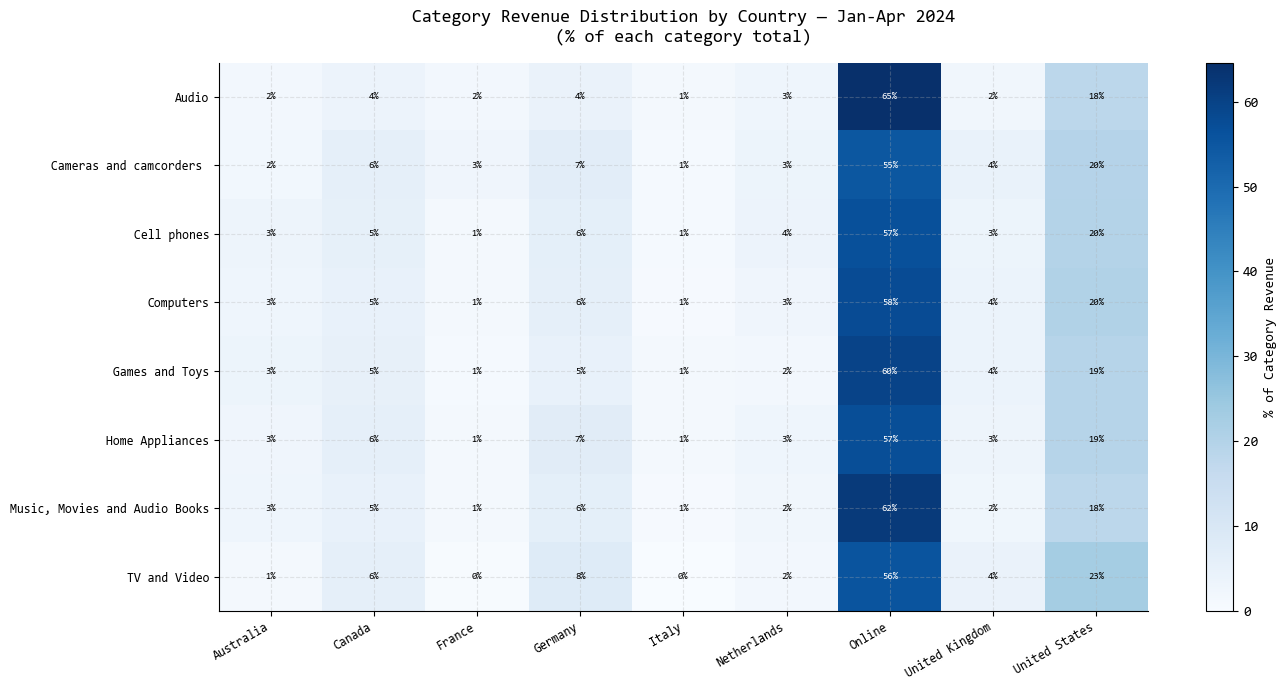


Dominant country per category:


,CategoryName,CountryName,Revenue
0,Audio,Online,"$40,844"
1,Cameras and camcorders,Online,"$115,497"
2,Cell phones,Online,"$282,320"
3,Computers,Online,"$513,603"
4,Games and Toys,Online,"$15,836"
5,Home Appliances,Online,"$236,229"
6,"Music, Movies and Audio Books",Online,"$116,153"
7,TV and Video,Online,"$151,469"


In [ ]:
# 3.L3.09 - Category revenue by country matrix Jan-Apr 2024
df_cat_country = pd.read_sql("""
    SELECT TOP 200
        p.CategoryName,
        st.CountryName,
        SUM(s.NetPrice) AS Revenue
    FROM Data.Sales s
    JOIN Data.Product p ON s.ProductKey = p.ProductKey
    JOIN Data.Store st ON s.StoreKey = st.StoreKey
    WHERE MONTH(s.OrderDate) BETWEEN 1 AND 4
      AND YEAR(s.OrderDate) = 2024
    GROUP BY p.CategoryName, st.CountryName
    ORDER BY p.CategoryName, Revenue DESC
""", cnxn)

pivot_rev = df_cat_country.pivot(index='CategoryName', columns='CountryName', values='Revenue').fillna(0)
# Normalize to % of category total
pivot_pct = pivot_rev.div(pivot_rev.sum(axis=1), axis=0) * 100

import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'Consolas','figure.facecolor':'white','axes.facecolor':'white'})

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot_pct.values, cmap='Blues', aspect='auto', vmin=0, vmax=pivot_pct.values.max())

ax.set_xticks(range(len(pivot_pct.columns)))
ax.set_xticklabels(pivot_pct.columns, rotation=30, ha='right', fontsize=9, fontfamily='Consolas')
ax.set_yticks(range(len(pivot_pct.index)))
ax.set_yticklabels(pivot_pct.index, fontsize=9, fontfamily='Consolas')

for i in range(len(pivot_pct.index)):
    for j in range(len(pivot_pct.columns)):
        val = pivot_pct.values[i, j]
        rev = pivot_rev.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                    fontsize=7, color='black' if val < 50 else 'white', fontfamily='Consolas')

plt.colorbar(im, ax=ax, label='% of Category Revenue')
ax.set_title('Category Revenue Distribution by Country — Jan-Apr 2024\n(% of each category total)', fontsize=13, fontfamily='Consolas', pad=15)
plt.tight_layout()
plt.show()

# Top country per category
top_country = df_cat_country.loc[df_cat_country.groupby('CategoryName')['Revenue'].idxmax()][['CategoryName','CountryName','Revenue']]
print("\nDominant country per category:")
display(top_country.reset_index(drop=True).style.format({'Revenue':'${:,.0f}'}))

### Key Insight — 3.L3.09
**The Online channel dominates every single product category — ranging from 55% (Cameras) to 65% (Audio) of each category's total revenue — making it the single most important sales channel for all 8 categories.**
The United States is the largest physical market for all categories (18–23% of category revenue), followed by Germany (5–8%). All other physical markets (France, Canada, Australia, UK, Italy, Netherlands) contribute 1–7% each.
This means any category strategy must be predominantly an online strategy — and that improving online channel performance, profitability, and conversion has a 2–3× greater impact than any single physical market improvement.

> **Analysis Limitation:** Multi-currency revenues not FX-normalized — the Online channel shares may be slightly over- or under-stated depending on exchange rate movements. Germany's prominence may partly reflect USD/EUR exchange rate effects.